# **Estimando $\pi$ con el método de Montecarlo**
## Aplicaciones de generadores congruenciales lineales y numeros pseudoaleatorios

*Simulacion Computacional*<br>
*Generacion de numeros aleatorios — Métodos de Montecarlo*<br>
*Universidad de los Llanos*
---


## 1. La idea: estimar $\pi$ lanzando "dardos"

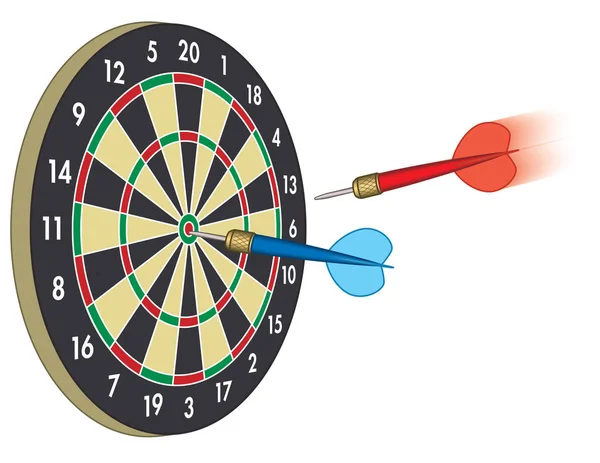

Imagina un cuadrado de lado 2 (de $-1$ a $1$ en cada eje) con un circulo de
radio 1 inscrito en el.

- Area del cuadrado: $A_{cuadrado} = 2 \times 2 = 4$
- Area del circulo: $A_{circulo} = \pi r^2 = \pi$

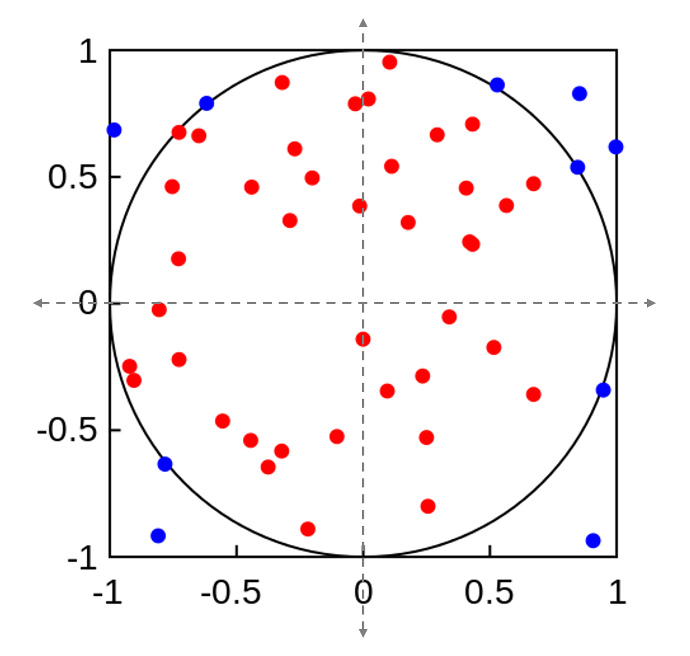

Si lanzamos puntos **al azar y de forma uniforme** dentro del cuadrado, la
**proporcion** de puntos que caen dentro del circulo debe aproximarse a la
razon entre las areas:

$$\frac{\text{puntos dentro del circulo}}{\text{puntos totales}} \approx \frac{A_{circulo}}{A_{cuadrado}} = \frac{\pi}{4}$$

Despejando:

$$\pi \approx 4 \times \frac{\text{puntos dentro del circulo}}{\text{puntos totales}}$$

Este es un ejemplo minimo, pero completo, de **metodo de Montecarlo**: usar
muestreo aleatorio para aproximar una cantidad deterministica (aqui, $\pi$).

**El ingrediente critico es la palabra "azar".** Todo el metodo depende de
tener numeros aleatorios (o pseudoaleatorios) de buena calidad: uniformemente
distribuidos y sin correlaciones ocultas. Por eso, antes de estimar $\pi$,
vamos a construir y auditar nuestro propio generador de numeros
pseudoaleatorios.


In [1]:
# Librerias que usaremos en todo el notebook
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (necesario para proyeccion 3D)
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, FloatSlider, IntSlider, Dropdown, fixed
from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Librerias cargadas correctamente")


Librerias cargadas correctamente


## 2. Generadores congruenciales lineales (LCG)

Un **generador congruencial lineal** produce una secuencia de enteros
$X_0, X_1, X_2, \dots$ mediante la relacion de recurrencia:

$$X_{n+1} = (a \cdot X_n + c) \; \bmod \; m$$

donde:

| Parametro | Significado |
|---|---|
| $X_0$ | **semilla** (seed): valor inicial |
| $a$   | **multiplicador** |
| $c$   | **incremento** |
| $m$   | **modulo** (define el rango: $0 \le X_n < m$) |

Para obtener numeros "uniformes" en $[0, 1)$ simplemente normalizamos:

$$U_n = \frac{X_n}{m}$$

### ¿Cuándo un LCG es "bueno"?

Un LCG es deterministico y su secuencia **siempre se repite** despues de,
como maximo, $m$ pasos (a esto se le llama **periodo**). Un buen generador
es aquel que:

1. Tiene **periodo completo** (recorre los $m$ valores posibles antes de repetirse).
2. Sus numeros se ven **uniformemente distribuidos**.
3. No presenta **correlaciones seriales** obvias entre numeros consecutivos.

**Teorema de Hull-Dobell (1962):** un LCG tiene periodo completo (igual a
$m$) si y solo si se cumplen simultaneamente:

1. $\gcd(c, m) = 1$ (c y m son coprimos)
2. $a - 1$ es divisible por todos los factores primos de $m$
3. Si $m$ es multiplo de 4, entonces $a - 1$ tambien debe ser multiplo de 4

Estas condiciones garantizan periodo completo, **pero no garantizan buena
calidad estadistica** (uniformidad "fina", ausencia de patrones). Por eso,
ademas del teorema, en la practica se usan parametros que han sido
verificados con pruebas estadisticas rigurosas (como el *test espectral*).

### Algunos parametros celebres

| Generador | $a$ | $c$ | $m$ | Es bueno? |
|---|---|---|---|---|
| Numerical Recipes | 1664525 | 1013904223 | $2^{32}$ | Si |
| ANSI C / glibc (`rand`) | 1103515245 | 12345 | $2^{31}$ | Razonable |
| Borland C/C++ | 22695477 | 1 | $2^{32}$ | Si |
| Minimal Standard (Park-Miller) | 16807 | 0 | $2^{31}-1$ | Si (multiplicativo) |
| **RANDU** (IBM, anos 60) | 65539 | 0 | $2^{31}$ | **Celebremente malo** |

`RANDU` se uso ampliamente en los anos 60 y 70 hasta que se descubrio que
sus tripletas $(U_n, U_{n+1}, U_{n+2})$ **no llenan el espacio 3D**: caen
sobre solo **15 planos paralelos**. Lo usaremos mas abajo como el ejemplo
perfecto de "generador malo" para comparar contra uno bueno.


In [2]:
class LCG:
    """Generador Congruencial Lineal:  X_{n+1} = (a * X_n + c) mod m

    Parameters
    ----------
    a, c, m : int
        Parametros del generador.
    seed : int
        Semilla inicial X0 (0 <= seed < m).
    """

    def __init__(self, a, c, m, seed=1):
        assert m > 0, "m debe ser positivo"
        assert 0 <= seed < m, "la semilla debe estar en [0, m)"
        self.a = a
        self.c = c
        self.m = m
        self.seed = seed
        self.state = seed

    def next_int(self):
        """Devuelve el siguiente entero X_n en [0, m)."""
        self.state = (self.a * self.state + self.c) % self.m
        return self.state

    def next_float(self):
        """Devuelve el siguiente numero U_n en [0, 1)."""
        return self.next_int() / self.m

    def reset(self):
        """Reinicia el generador a su semilla original."""
        self.state = self.seed

    def sample(self, n):
        """Genera un arreglo de n numeros pseudoaleatorios en [0, 1)."""
        return np.array([self.next_float() for _ in range(n)])

    def period(self, max_steps=None):
        """Calcula el periodo real de la secuencia (util para m pequenos).

        Recorre la secuencia desde la semilla hasta que un valor se repite.
        Para m grandes (como 2**31) esto seria muy lento: usar max_steps
        para poner un limite de seguridad.
        """
        max_steps = max_steps or self.m
        seen = {}
        x = self.seed
        for i in range(max_steps):
            if x in seen:
                return i - seen[x]  # longitud del ciclo
            seen[x] = i
            x = (self.a * x + self.c) % self.m
        return max_steps  # no se repitio dentro del limite

    def __repr__(self):
        return f"LCG(a={self.a}, c={self.c}, m={self.m}, seed={self.seed})"


def hull_dobell_check(a, c, m):
    """Verifica las 3 condiciones del Teorema de Hull-Dobell.

    Devuelve (cumple: bool, detalle: dict) explicando cada condicion.
    """
    def prime_factors(n):
        factors = set()
        d = 2
        while d * d <= n:
            while n % d == 0:
                factors.add(d)
                n //= d
            d += 1
        if n > 1:
            factors.add(n)
        return factors

    cond1 = math.gcd(c, m) == 1
    factors_m = prime_factors(m)
    cond2 = all((a - 1) % p == 0 for p in factors_m) if factors_m else True
    cond3 = ((a - 1) % 4 == 0) if (m % 4 == 0) else True

    detalle = {
        "1) gcd(c, m) == 1": cond1,
        "2) (a-1) divisible por cada factor primo de m": cond2,
        f"   factores primos de m: {sorted(factors_m)}": None,
        "3) si 4 | m, entonces 4 | (a-1)": cond3,
    }
    cumple = cond1 and cond2 and cond3
    return cumple, detalle


print("Clase LCG y verificador de Hull-Dobell definidos")


Clase LCG y verificador de Hull-Dobell definidos


### Probemos nuestro LCG con un generador "bueno" (Numerical Recipes)

Generamos los primeros numeros y verificamos el Teorema de Hull-Dobell.


In [3]:
a_bueno, c_bueno, m_bueno = 1664525, 1013904223, 2**32

cumple, detalle = hull_dobell_check(a_bueno, c_bueno, m_bueno)
print(f"Cumple Hull-Dobell? -> {cumple}\n")
for k, v in detalle.items():
    print(f"  {k}: {v}" if v is not None else f"  {k}")

lcg_bueno = LCG(a_bueno, c_bueno, m_bueno, seed=42)
print("\nPrimeros 10 numeros pseudoaleatorios U_n:")
print(np.round(lcg_bueno.sample(10), 5))


Cumple Hull-Dobell? -> True

  1) gcd(c, m) == 1: True
  2) (a-1) divisible por cada factor primo de m: True
     factores primos de m: [2]
  3) si 4 | m, entonces 4 | (a-1): True

Primeros 10 numeros pseudoaleatorios U_n:
[0.25235 0.08813 0.57728 0.22255 0.37566 0.02566 0.44728 0.11846 0.87381
 0.99463]


### Ahora probemos con `RANDU`, el generador celebremente malo

Con $m = 2^{31}$ el periodo es astronomico, pero eso **no** dice nada sobre
la calidad estadistica de la secuencia: sus numeros presentan una fuerte
correlacion oculta, como veremos en la siguiente seccion.


In [4]:
a_randu, c_randu, m_randu = 65539, 0, 2**31

cumple, detalle = hull_dobell_check(a_randu, c_randu, m_randu)
print(f"RANDU cumple Hull-Dobell (periodo completo)? -> {cumple}\n")
for k, v in detalle.items():
    print(f"  {k}: {v}" if v is not None else f"  {k}")

# Nota: RANDU es multiplicativo (c=0). En la practica tiene periodo largo,
# pero su defecto NO es el periodo: es la estructura reticular de sus
# tripletas, como veremos a continuacion.

lcg_randu = LCG(a_randu, c_randu, m_randu, seed=1)
print("\nPrimeros 10 numeros pseudoaleatorios U_n con RANDU:")
print(np.round(lcg_randu.sample(10), 5))


RANDU cumple Hull-Dobell (periodo completo)? -> False

  1) gcd(c, m) == 1: False
  2) (a-1) divisible por cada factor primo de m: True
     factores primos de m: [2]
  3) si 4 | m, entonces 4 | (a-1): False

Primeros 10 numeros pseudoaleatorios U_n con RANDU:
[3.0000e-05 1.8000e-04 8.2000e-04 3.3000e-03 1.2360e-02 4.4490e-02
 1.5573e-01 5.3394e-01 8.0204e-01 6.8000e-03]


### Un ejemplo pequeno y muy visual: el periodo con $m$ chico

Para entender el concepto de "periodo" de forma tangible, usemos un modulo
pequeno donde podamos ver la secuencia completa repetirse.


In [5]:
# Ejemplo con m pequeno: comparamos una eleccion BUENA y una MALA de (a, c)
m_chico = 16

# Buena eleccion (cumple Hull-Dobell): a-1 multiplo de 2 (unico factor primo de 16)
#                                       y de 4 (porque 16 es multiplo de 4); gcd(c,16)=1
a1, c1 = 5, 1
# Mala eleccion: no cumple Hull-Dobell
a2, c2 = 4, 2

for (a, c, nombre) in [(a1, c1, "BUENA"), (a2, c2, "MALA")]:
    cumple, _ = hull_dobell_check(a, c, m_chico)
    g = LCG(a, c, m_chico, seed=0)
    periodo = g.period()
    g.reset()
    secuencia = [g.next_int() for _ in range(16)]
    print(f"Eleccion {nombre}:  a={a}, c={c}, m={m_chico}  "
          f"| Hull-Dobell={cumple} | periodo real={periodo}")
    print(f"  Secuencia: {secuencia}\n")


Eleccion BUENA:  a=5, c=1, m=16  | Hull-Dobell=True | periodo real=16
  Secuencia: [1, 6, 15, 12, 13, 2, 11, 8, 9, 14, 7, 4, 5, 10, 3, 0]

Eleccion MALA:  a=4, c=2, m=16  | Hull-Dobell=False | periodo real=1
  Secuencia: [2, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]



Observa como la eleccion **mala** de $(a, c)$ produce un periodo mucho
menor que $m$: la secuencia se queda "atrapada" repitiendo muy pocos
valores, lo cual es catastrofico para una simulacion (solo tendriamos
unos pocos numeros "aleatorios" distintos). La eleccion **buena** recorre
los 16 valores posibles antes de repetirse.


## 3. Auditando la calidad de un generador

Antes de confiar un generador para una simulacion de Montecarlo conviene
hacerle un par de pruebas visuales rapidas:

1. **Uniformidad marginal**: un histograma de los $U_n$ debe verse plano.
2. **Test serial / test espectral**: graficar pares consecutivos
   $(U_n, U_{n+1})$ (y tripletas $(U_n, U_{n+1}, U_{n+2})$) no debe mostrar
   patrones, rejillas ni planos. Si aparecen, hay correlacion serial: el
   generador "recuerda" el valor anterior de forma visible, lo cual viola
   el supuesto de independencia que Montecarlo necesita.

Vamos a comparar nuestro generador **bueno** (Numerical Recipes) contra
**RANDU**.


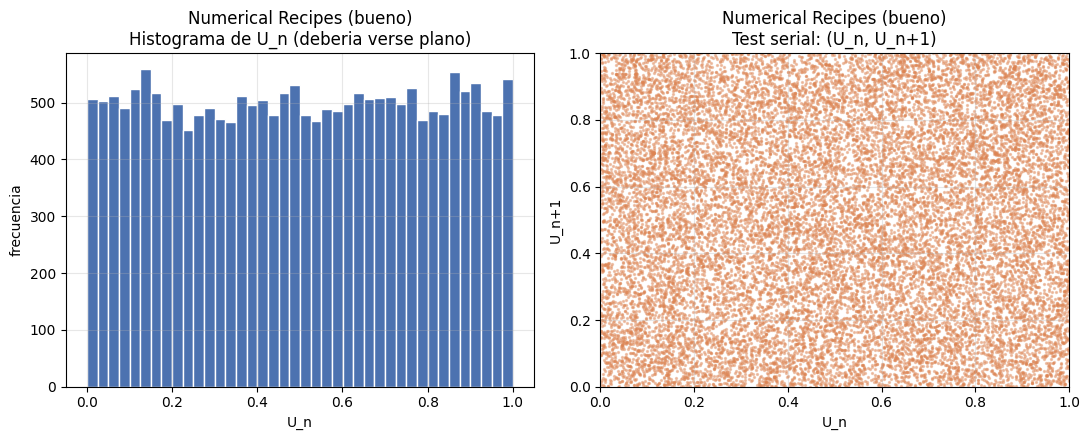

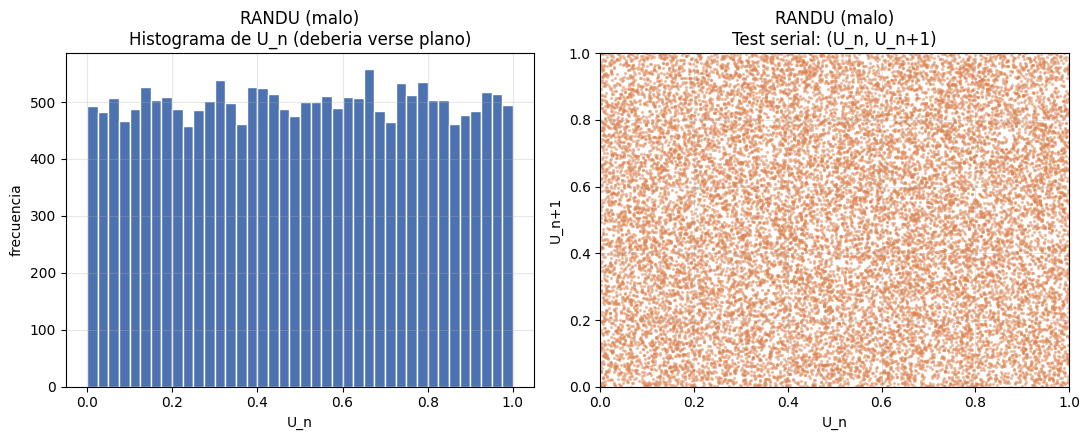

In [6]:
def graficar_diagnostico(gen, n=20000, titulo="Generador"):
    """Dibuja: histograma de uniformidad + dispersion serial (U_n, U_n+1)."""
    gen.reset()
    u = gen.sample(n)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].hist(u, bins=40, color="#4C72B0", edgecolor="white")
    axes[0].set_title(f"{titulo}\nHistograma de U_n (deberia verse plano)")
    axes[0].set_xlabel("U_n")
    axes[0].set_ylabel("frecuencia")

    axes[1].scatter(u[:-1], u[1:], s=2, alpha=0.4, color="#DD8452")
    axes[1].set_title(f"{titulo}\nTest serial: (U_n, U_n+1)")
    axes[1].set_xlabel("U_n")
    axes[1].set_ylabel("U_n+1")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


graficar_diagnostico(LCG(a_bueno, c_bueno, m_bueno, seed=42), titulo="Numerical Recipes (bueno)")
graficar_diagnostico(LCG(a_randu, c_randu, m_randu, seed=1), titulo="RANDU (malo)")


En el plano 2D, `RANDU` puede parecer razonablemente uniforme: su
defecto es mas sutil y solo se revela en **3 dimensiones**. Grafiquemos las
tripletas $(U_n, U_{n+1}, U_{n+2})$ y rotemos el punto de vista.


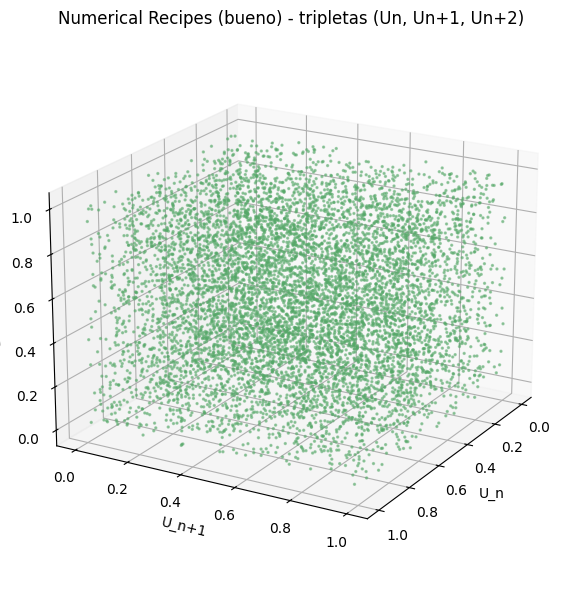

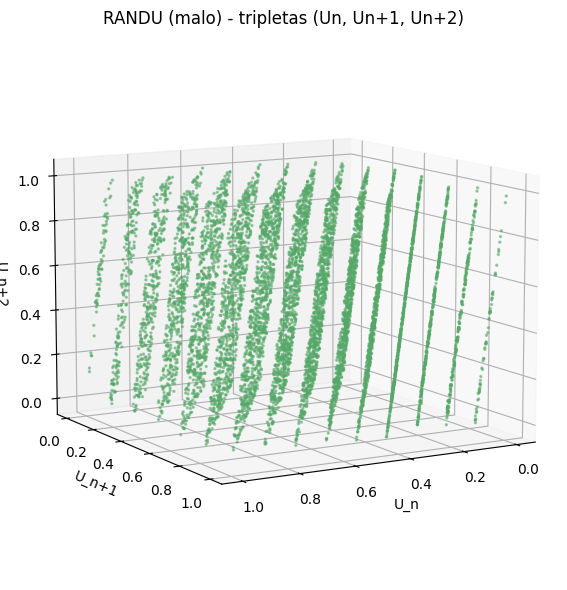

In [7]:
def graficar_triples_3d(gen, n=8000, titulo="Generador", elev=20, azim=30):
    """Grafica tripletas consecutivas (U_n, U_n+1, U_n+2) en 3D."""
    gen.reset()
    u = gen.sample(n + 2)
    x, y, z = u[:-2], u[1:-1], u[2:]

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, s=2, alpha=0.5, color="#55A868")
    ax.set_title(titulo)
    ax.set_xlabel("U_n")
    ax.set_ylabel("U_n+1")
    ax.set_zlabel("U_n+2")
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


# Generador bueno: la nube de puntos llena el cubo de forma pareja
graficar_triples_3d(LCG(a_bueno, c_bueno, m_bueno, seed=42),
                     titulo="Numerical Recipes (bueno) - tripletas (Un, Un+1, Un+2)",
                     elev=20, azim=30)

# RANDU: rotando el angulo de vista, los puntos colapsan sobre 15 planos
graficar_triples_3d(LCG(a_randu, c_randu, m_randu, seed=1),
                     titulo="RANDU (malo) - tripletas (Un, Un+1, Un+2)",
                     elev=10, azim=60)


**Esto es exactamente el descubrimiento historico que hundio a `RANDU`**:
vistas desde el angulo correcto, las tripletas de `RANDU` **no llenan el
cubo** sino que colapsan sobre solo **15 planos paralelos**. Cualquier
simulacion de Montecarlo que dependiera de tripletas de `RANDU` (por
ejemplo, para generar puntos en 3D) estaria sistematicamente sesgada,
¡aunque el histograma 1D se viera perfecto!

> Prueba cambiar `elev` y `azim` en la celda anterior para rotar la vista
> y encontrar el angulo donde los planos de RANDU se ven mas claramente
> (una buena referencia es `elev=10, azim=60`, pero explora tu mismo).

**Moraleja:** elegir bien $(a, c, m)$ no es un detalle menor. Un generador
con periodo completo (Hull-Dobell) puede seguir teniendo defectos
estructurales serios. Por eso los generadores "buenos" de la tabla anterior
fueron seleccionados tras pasar pruebas estadisticas exigentes como el
*test espectral*.


## 4. Estimando $\pi$ con Montecarlo

Ahora que sabemos generar (y auditar) numeros pseudoaleatorios, implementemos
el algoritmo descrito en la introduccion:

1. Generar pares $(U_{2i}, U_{2i+1})$ con nuestro LCG.
2. Convertirlos a coordenadas $(x, y)$ en el cuadrado $[-1, 1] \times [-1, 1]$
   mediante $x = 2U - 1$.
3. Contar cuantos puntos caen dentro del circulo unitario: $x^2 + y^2 \le 1$.
4. Estimar $\pi \approx 4 \times (\text{puntos dentro} / \text{puntos totales})$.


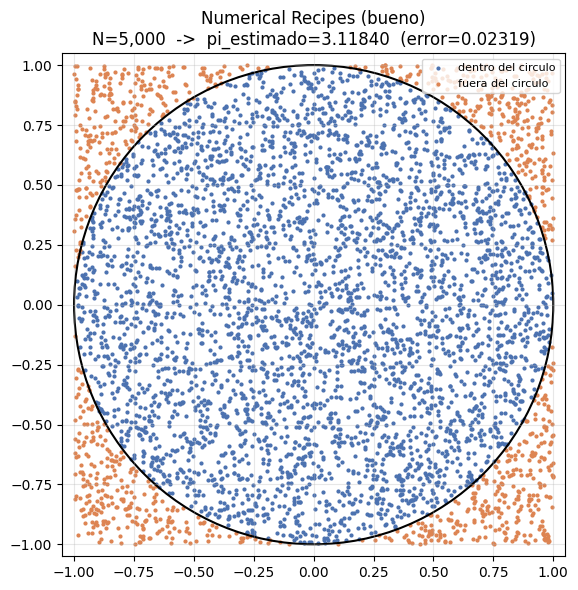

Valor real de pi: 3.14159


In [10]:
def montecarlo_pi(gen, n_puntos):
    """Estima pi lanzando n_puntos puntos aleatorios generados por 'gen'.

    Devuelve (estimacion_pi, x, y, dentro) donde x, y son las coordenadas
    de los puntos y 'dentro' es un arreglo booleano indicando cuales
    cayeron dentro del circulo unitario.
    """
    gen.reset()
    u = gen.sample(2 * n_puntos)
    x = 2 * u[0::2] - 1   # primeras n_puntos U -> x en [-1, 1]
    y = 2 * u[1::2] - 1   # siguientes n_puntos U -> y en [-1, 1]

    dentro = (x**2 + y**2) <= 1.0
    estimacion = 4.0 * dentro.sum() / n_puntos
    return estimacion, x, y, dentro


def graficar_montecarlo(gen, n_puntos, titulo="Estimacion de pi"):
    estimacion, x, y, dentro = montecarlo_pi(gen, n_puntos)
    error = abs(estimacion - math.pi)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(x[dentro], y[dentro], s=4, color="#4C72B0", label="dentro del circulo")
    ax.scatter(x[~dentro], y[~dentro], s=4, color="#DD8452", label="fuera del circulo")

    circulo = plt.Circle((0, 0), 1, fill=False, color="black", linewidth=1.5)
    ax.add_artist(circulo)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(f"{titulo}\nN={n_puntos:,}  ->  pi_estimado={estimacion:.5f}  "
                 f"(error={error:.5f})")
    plt.tight_layout()
    plt.show()
    return estimacion


lcg_demo = LCG(a_bueno, c_bueno, m_bueno, seed=42)
_ = graficar_montecarlo(lcg_demo, 5000, titulo="Numerical Recipes (bueno)")
print(f"Valor real de pi: {math.pi:.5f}")


### Convergencia: ¿Qué pasa cuando aumentamos N?

La teoria de Montecarlo predice que el error de la estimacion decrece de
forma proporcional a $1/\sqrt{N}$, sin importar la dimension del problema:
es una convergencia **lenta** pero **muy robusta**. Verifiquemos esto
empiricamente.


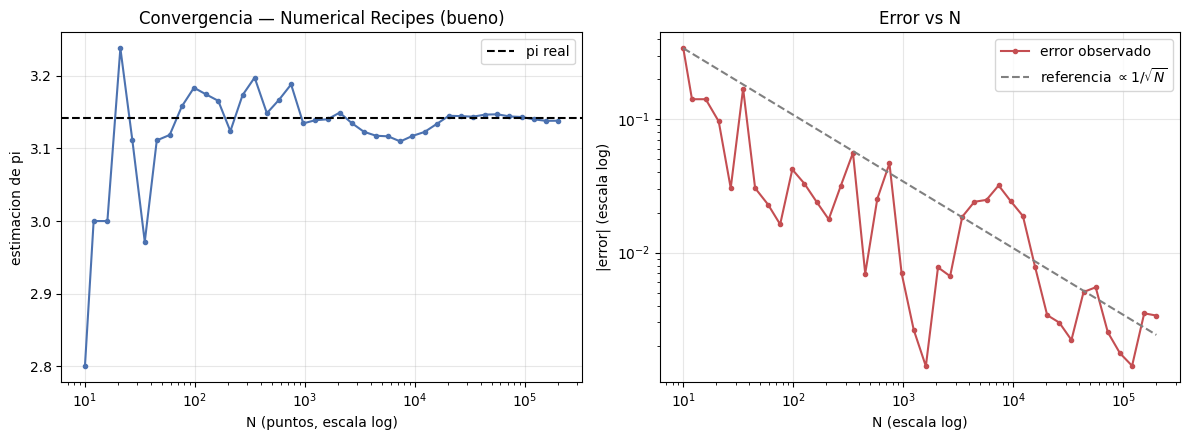

In [11]:
def curva_convergencia(gen, n_max=200000, puntos_grafica=40, titulo="Generador"):
    gen.reset()
    Ns = np.unique(np.logspace(1, math.log10(n_max), puntos_grafica).astype(int))
    errores = []
    estimaciones = []
    for n in Ns:
        est, _, _, _ = montecarlo_pi(gen, int(n))
        estimaciones.append(est)
        errores.append(abs(est - math.pi))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(Ns, estimaciones, color="#4C72B0", marker="o", markersize=3)
    axes[0].axhline(math.pi, color="black", linestyle="--", label="pi real")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("N (puntos, escala log)")
    axes[0].set_ylabel("estimacion de pi")
    axes[0].set_title(f"Convergencia — {titulo}")
    axes[0].legend()

    axes[1].loglog(Ns, errores, color="#C44E52", marker="o", markersize=3, label="error observado")
    ref = errores[0] * np.sqrt(Ns[0] / Ns)
    axes[1].loglog(Ns, ref, color="gray", linestyle="--", label=r"referencia $\propto 1/\sqrt{N}$")
    axes[1].set_xlabel("N (escala log)")
    axes[1].set_ylabel("|error| (escala log)")
    axes[1].set_title("Error vs N")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


curva_convergencia(LCG(a_bueno, c_bueno, m_bueno, seed=42), titulo="Numerical Recipes (bueno)")


Observa que los puntos de error (rojo) siguen aproximadamente la
pendiente de la linea de referencia $1/\sqrt{N}$ (gris punteada) en escala
log-log. Esto es una firma caracteristica de casi cualquier metodo de
Montecarlo: **para reducir el error a la mitad, necesitas 4 veces mas
puntos** — mejorar la precision es "caro", pero el metodo es muy general y
facil de paralelizar.


## 5. Ahora te toca a ti: explora de forma interactiva

Usa los controles deslizantes para:

- Cambiar los parametros $(a, c, m)$ y la semilla de tu propio LCG.
- Ver en vivo el diagrama de Montecarlo y la estimacion de $\pi$ resultante.
- Verificar si tu eleccion cumple el Teorema de Hull-Dobell.

**Sugerencias para experimentar:**
- Prueba primero los valores por defecto (un generador bueno).
- Luego escribe los parametros de `RANDU` (a=65539, c=0, m=2147483648) y
  observa que la estimacion de $\pi$ ya no es tan mala en 2D (el defecto de
  RANDU es sutil), pero el patron del test serial en la seccion 3 si lo
  delata.
- Prueba un generador deliberadamente malo, por ejemplo a=4, c=2, m=16
  (nuestro ejemplo de periodo corto): notaras que con pocos puntos el
  patron se repite y la estimacion no mejora aunque aumentes N.


In [16]:
def explorar_lcg(a, c, m, seed, n_puntos):
    m = int(m)
    seed = int(seed) % m
    gen = LCG(int(a), int(c), m, seed=seed)

    cumple, detalle = hull_dobell_check(int(a), int(c), m)
    estimacion = graficar_montecarlo(
        gen, int(n_puntos),
        titulo=f"LCG(a={a}, c={c}, m={m}, seed={seed})"
    )

    print(f"Hull-Dobell (periodo completo garantizado): {cumple}")
    print(f"pi real       = {math.pi:.6f}")
    print(f"pi estimado   = {estimacion:.6f}")
    print(f"error absoluto = {abs(estimacion - math.pi):.6f}")


interact_manual(
    explorar_lcg,
    a=IntSlider(value=1664525, min=1, max=100000, step=1, description="a"),
    c=IntSlider(value=1013904223, min=0, max=2_000_000_000, step=1, description="c"),
    m=Dropdown(
        options=[
            ("2^31 (2147483648)", 2**31),
            ("2^31 - 1 (2147483647)", 2**31 - 1),
            ("2^32 (4294967296)", 2**32),
            ("16 (para ver periodos cortos)", 16),
        ],
        value=2**31,
        description="m",
    ),
    seed=IntSlider(value=42, min=0, max=100000, step=1, description="semilla"),
    n_puntos=IntSlider(value=6000, min=100, max=20000, step=100, description="N puntos"),
);


interactive(children=(IntSlider(value=100000, description='a', max=100000, min=1), IntSlider(value=1013904223,…

> `interact_manual` muestra un boton **"Run Interact"**: cambia los
> controles y presiona el boton para recalcular (asi evitamos recalcular
> en cada pequeno movimiento del mouse, lo cual seria lento con muchos
> puntos).


## 6. Comparacion directa: generador bueno vs generador malo

Esta ultima seccion interactiva compara, lado a lado y para el mismo N,
la estimacion de $\pi$ obtenida con tres generadores distintos:

- **Numerical Recipes** (bueno)
- **RANDU** (malo, defecto en 3D)
- **Periodo corto** (a=4, c=2, m=16 — malisimo, se repite casi de inmediato)

Mueve el control de N y observa como el generador de periodo corto se
"estanca": aunque aumentes muchisimo el numero de puntos, como solo puede
producir unos pocos valores distintos, la estimacion no mejora (no
converge a $\pi$).


In [17]:
PRESETS = {
    "Numerical Recipes (bueno)": dict(a=1664525, c=1013904223, m=2**32, seed=42),
    "RANDU (malo, defecto 3D)": dict(a=65539, c=0, m=2**31, seed=1),
    "Periodo corto (malisimo)": dict(a=4, c=2, m=16, seed=0),
}


def comparar_generadores(n_puntos):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, (nombre, params) in zip(axes, PRESETS.items()):
        gen = LCG(**params)
        estimacion, x, y, dentro = montecarlo_pi(gen, n_puntos)
        error = abs(estimacion - math.pi)

        ax.scatter(x[dentro], y[dentro], s=4, color="#4C72B0")
        ax.scatter(x[~dentro], y[~dentro], s=4, color="#DD8452")
        circulo = plt.Circle((0, 0), 1, fill=False, color="black", linewidth=1.2)
        ax.add_artist(circulo)
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        ax.set_aspect("equal")
        ax.set_title(f"{nombre}\npi~={estimacion:.4f}  error={error:.4f}", fontsize=10)

    plt.tight_layout()
    plt.show()


interact(
    comparar_generadores,
    n_puntos=IntSlider(value=4000, min=200, max=20000, step=200,
                        description="N puntos", continuous_update=False),
);


interactive(children=(IntSlider(value=4000, continuous_update=False, description='N puntos', max=20000, min=20…

Con el generador de **periodo corto** notaras un patron geometrico muy
regular (rejilla de pocos puntos repetidos) que **no cambia** aunque N
crezca: es la evidencia visual mas directa de por que un mal generador
arruina una simulacion de Montecarlo, sin importar cuanto "presupuesto
computacional" le dediques.


## 7. Complemento: interfaz web interactiva

Para seguir explorando estos mismos conceptos sin necesidad de ejecutar
Python, se preparo una **pagina web interactiva** con:

- Controles para $a$, $c$, $m$ y la semilla de un LCG.
- Presets de generadores buenos (Numerical Recipes, Minimal Standard) y
  malos (RANDU, periodo corto).
- Visualizacion animada del muestreo de Montecarlo (punto por punto).
- Grafica de convergencia de la estimacion de $\pi$ en tiempo real.
- Diagrama de dispersion serial $(U_n, U_{n+1})$ para inspeccionar
  patrones.

Pidele el enlace a tu profesor/a, o usa la version que te compartieron
junto con este notebook.


## 8. Ejercicios propuestos

1. **Verificacion teorica.** Para el generador ANSI C
   ($a=1103515245$, $c=12345$, $m=2^{31}$), usa `hull_dobell_check` para
   verificar si tiene periodo completo. Justifica el resultado a mano
   calculando los factores primos de $m$.

2. **Disena tu propio "generador malo".** Encuentra valores de $(a, c, m)$
   (con $m$ moderado, por ejemplo entre 100 y 1000) que **no** cumplan
   Hull-Dobell, calcula su periodo real con `.period()` y comprueba cuanto
   se aleja del maximo posible ($m$).

3. **Otra figura geometrica.** Modifica `montecarlo_pi` para, en lugar de
   estimar el area de un circulo, estimar el area bajo la curva
   $y = \sin(x)$ entre $0$ y $\pi$ usando el mismo LCG. Compara tu
   resultado con el valor exacto (integral definida = 2).

4. **Semillas y reproducibilidad.** Ejecuta `montecarlo_pi` con el mismo
   generador pero 5 semillas distintas y el mismo N. Calcula la
   desviacion estandar de las 5 estimaciones de pi. Que pasa con esa
   desviacion si aumentas N por un factor de 100?

5. **Comparacion con `numpy.random`.** Repite el experimento de la seccion
   4 usando `numpy.random.default_rng()` (que internamente usa un
   generador mucho mas moderno, PCG64) en lugar de tu LCG. Comparen la
   velocidad de convergencia frente al LCG bueno: deberian ser similares,
   porque ambos son generadores de "buena calidad" para este proposito.

6. **(Reto) Encontrar los 15 planos de RANDU.** Usando la funcion
   `graficar_triples_3d`, experimenta con distintos valores de `elev` y
   `azim` hasta lograr una vista donde puedas contar aproximadamente
   cuantos planos distintos se distinguen en la nube de puntos de RANDU.


## Referencias

- Hull, T. E., & Dobell, A. R. (1962). *Random Number Generators*. SIAM Review, 4(3), 230-254.
- Marsaglia, G. (1968). *Random numbers fall mainly in the planes*. PNAS, 61(1), 25-28. (El articulo que expuso el defecto de RANDU.)
- Press, W. H., Teukolsky, S. A., Vetterling, W. T., & Flannery, B. P. *Numerical Recipes* — capitulo sobre generadores de numeros aleatorios.
- Knuth, D. E. *The Art of Computer Programming, Vol. 2: Seminumerical Algorithms* — capitulo 3, la referencia clasica sobre generadores congruenciales y pruebas estadisticas (incluye el test espectral).
- L'Ecuyer, P. (1999). *Tables of linear congruential generators of different sizes and good lattice structure*. Mathematics of Computation.

---

*Notebook generado como material didactico para el curso de Simulacion Computacional — tema de numeros aleatorios y metodos de Montecarlo.*
